In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
from diabnet.apply_ensemble import Predictor
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble

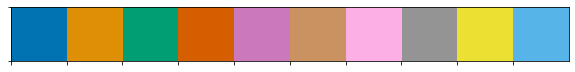

In [88]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [222]:
fn = "../datasets/visits_sp_changed_test_positivo_1000_random_0.csv"
def dataset_test_first_diag(fn):
    df = pd.read_csv(fn)
    # seleciona as amostras negativas e agrupa por id pegando a MAIOR idade
    neg  = df[df.T2D == 0][['id','AGE']].groupby('id').max()
    # seleciona as amostras positivas e agrupa por id pegando a MENOR idade
    pos  = df[df.T2D == 1][['id','AGE']].groupby('id').min()
    dtmp = neg.join(pos, lsuffix='_neg', rsuffix='_pos')
    # filtra somente pacientes que a idade negativa < idade positiva
    dtmp = dtmp[dtmp.AGE_neg < dtmp.AGE_pos]
    tmp = pd.concat([pd.DataFrame({'AGE':dtmp.AGE_neg}),pd.DataFrame({'AGE':dtmp.AGE_pos})])
    tmp = tmp.reset_index()
    # Eu odeio a API do pandas!!!
    df = df.merge(tmp, on=['id','AGE'], how="inner")
    return df

df_first = dataset_test_first_diag(fn)
df_unique = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [233]:
def plot(df, id):
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    color_boxplot = sns.color_palette("cool", n_colors=20)
    plt.title(f"patient\n(id: {df['id'].iloc[id]}, age: {age}, diagnostic: {'positive' if label==1 else 'negative'})")
    sns.boxplot(x=[i for i in probs_life[1]], y=probs_life[0], showfliers=False, palette=[color_boxplot[int(np.median(a)*20)] for a in probs_life[0]]);
    plt.xlabel("age")
    plt.ylim(0,1);
    plt.subplot(122)
    plt.title("negative control\n(non-diabetic older than 60 years)")
    sns.boxplot(x=[i for i in neg_life[1]], y=neg_life[0], showfliers=False, palette=[color_boxplot[int(np.median(a)*20)] for a in neg_life[0]]);
    plt.xlabel("age")
    plt.ylim(0,1);

In [235]:
def plot2(df, id, age):
    plt.title(f"id: {df['id'].iloc[id]}, age: {age}, diagnostic: {'positive' if label==1 else 'negative'}")
    sns.boxplot(data=[probs,neg_at_same_age],showfliers=False, palette=[colors[8], colors[7]]);
    plt.ylim(0,1);
    plt.xticks([0,1],["patient", "negative controls"]);

In [223]:
ensemble = Ensemble('../diabnet/models/model-13-sp-soft-label-positives-2500-dropout0-bn-decay-flood-hyperopt-*')
c = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)
pred = Predictor(ensemble, c, "../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv")

../diabnet/models/model-13-sp-soft-label-positives-2500-dropout0-bn-decay-flood-hyperopt-*
NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [224]:
# true negatives are people older than 60 and negative
neg_life = pred.negatives_life(samples_per_model=1)

# Estudo de indivíduos 

Nesse notebook avaliaremos N tipos de indivíduos para entender o comportamento do classificador. São eles:

- Idoso, positivo.
- Idoso, negativo.
- Jovem, positivo.
- Jovem, negativo.

## 1 - Idoso positivo 

In [225]:
# individuos idosos e positivos
df = df_first
df[(df.T2D==1)&(df.AGE>50)].index

Int64Index([  1,   3,   7,   9,  13,  15,  17,  21,  25,  33,  35,  37,  39,
             41,  43,  47,  53,  59,  61,  65,  67,  73,  77,  83,  87,  91,
             93, 101, 103, 105, 107, 109, 111, 121, 123, 127, 131, 137, 149,
            155, 157, 159, 163, 165, 167, 169],
           dtype='int64')

In [226]:
id = 3
features = df[c].iloc[id].values
label = df["T2D"].iloc[id]

In [227]:
age = features[-4]; age

53

In [228]:
probs = pred.patient(features, age=age, samples_per_model=1)

In [229]:
neg_at_same_age = pred.negatives(age=age)

In [230]:
probs_life = pred.patient_life(features, samples_per_model=1)

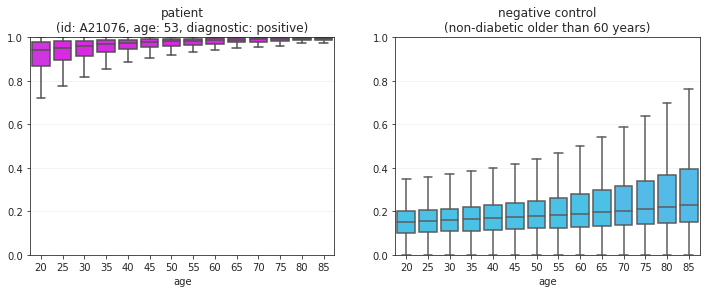

In [234]:
plot(df, id)

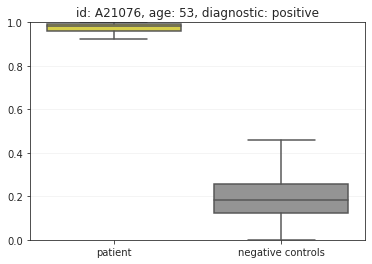

In [236]:
plot2(df, id, age)

## 2 - Idoso negativo

In [237]:
# individuos idosos e positivos
df = df_unique
df[(df.T2D==0)&(df.AGE>50)].index

Int64Index([  7,   8,  12,  18,  21,  26,  29,  31,  32,  34,
            ...
            502, 506, 509, 519, 525, 526, 530, 536, 538, 547],
           dtype='int64', length=153)

In [238]:
id = 21
features = df[c].iloc[id].values
label = df["T2D"].iloc[id]

In [239]:
age = features[-4]; age

56

In [240]:
probs = pred.patient(features, age=age, samples_per_model=1)

In [241]:
neg_at_same_age = pred.negatives(age=age)

In [242]:
probs_life = pred.patient_life(features, samples_per_model=1)

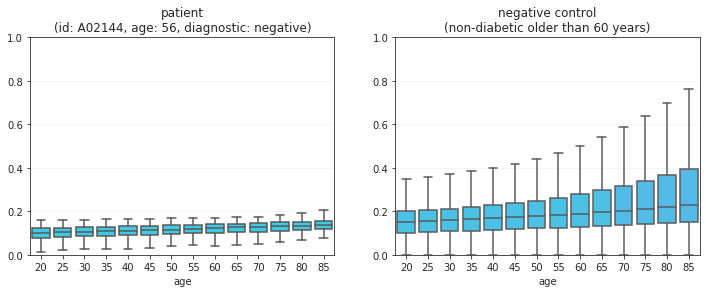

In [243]:
plot(df, id)

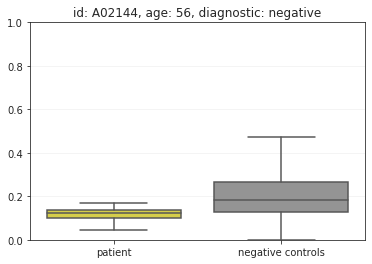

In [244]:
plot2(df, id, age)

## 3 - Jovem positivo

In [245]:
# individuos idosos e positivos
df = df_first
df[(df.T2D==1)&(df.AGE<30)].index

Int64Index([51, 133, 153], dtype='int64')

In [266]:
id = 153
features = df[c].iloc[id].values
label = df["T2D"].iloc[id]

In [267]:
age = features[-4]; age

28

In [268]:
probs = pred.patient(features, age=age, samples_per_model=1)

In [269]:
neg_at_same_age = pred.negatives(age=age)

In [270]:
probs_life = pred.patient_life(features, samples_per_model=1)

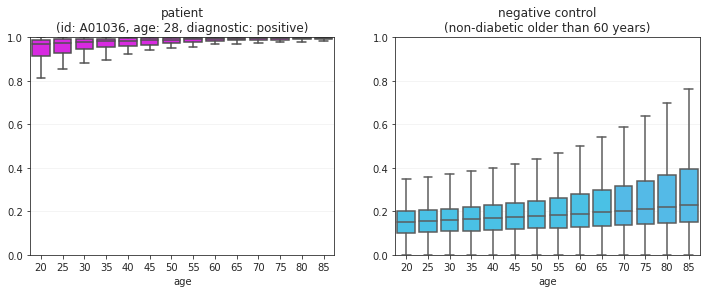

In [271]:
plot(df, id)

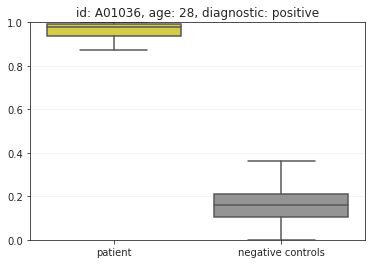

In [272]:
plot2(df, id, age)

## 4 - Jovem negativo

In [273]:
# individuos idosos e positivos
df = df_unique
df[(df.T2D==0)&(df.AGE<40)].index

Int64Index([  3,   4,  16,  22,  24,  27,  28,  30,  38,  39,
            ...
            513, 518, 521, 527, 531, 532, 537, 543, 544, 545],
           dtype='int64', length=131)

In [324]:
id = 513
features = df[c].iloc[id].values
label = df["T2D"].iloc[id]

In [325]:
age = features[-4]; age

35

In [326]:
probs = pred.patient(features, age=age, samples_per_model=1)

In [327]:
neg_at_same_age = pred.negatives(age=age)

In [328]:
probs_life = pred.patient_life(features, samples_per_model=1)

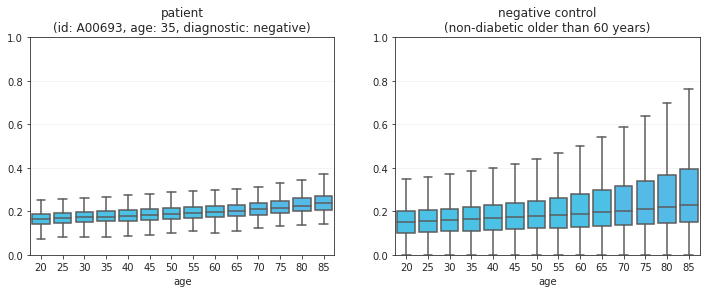

In [329]:
plot(df, id)

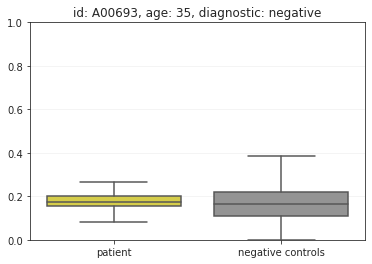

In [330]:
plot2(df, id, age)